In [1]:
import xarray as xr
import numpy as np
import xesmf as xe

In [2]:
# this is step 2 after applying sea ice mask and saving these files
# apply_ice_and_land_mask_to_JRA_outputs.ipynb

In [3]:
YEAR_START = 1959
YEAR_FIN = 2019

out_var_type = 'ocn'
with_ice_mask = True


PATH = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/MONTHLY/"
PATH_OUT = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/YEARLY/"

PATH_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl/cpl/hist/'
filename_raw = 'a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl.cpl.hi.1959-12-31-81000.nc'

if out_var_type == 'ocn':
    lat_raw = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['ocnExp_lat'].isel(time=0).drop_vars('time').rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
elif out_var_type == 'atm':
    lat_raw = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['atmImp_lat'].isel(time=0).drop_vars('time').rename({"atmImp_ny": "y", "atmImp_nx": "x"})


if out_var_type == 'ocn':
    variables = {
        "latent": "ocnExp_Foxx_lat",
        "sensible": "ocnExp_Foxx_sen",
        "swnet": "ocnExp_Foxx_swnet",
        "lwnet": "ocnExp_Foxx_lwnet"
    }
elif out_var_type == 'atm':
    variables = {
        "atm_swnet": "atmImp_Faxa_swnet"
    }

In [4]:
def convert_ocnExp_to_atmImp_mask(PATH, filename):
    '''
    PATH - path to raw model output files 
    filename - filename of one of these files (to read coords of ocnExp and atmImp)
    '''
    lat_in = xr.open_dataset(PATH + filename)['ocnExp_lat'].isel(time=0, drop = True)
    lon_in = xr.open_dataset(PATH + filename)['ocnExp_lon'].isel(time=0, drop = True) % 360

    mask = xr.open_dataset(PATH + filename, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "ocnExp_ny", "ocnImp_nx": "ocnExp_nx"})
    
    mask_in = xr.DataArray(mask.values, dims=("y", "x"),
                           coords={"lon": (("y", "x"), lon_in.values), "lat": (("y", "x"), lat_in.values)},
                           name="mask")
    
    
    lat_out = xr.open_dataset(PATH + filename)['atmImp_lat'].isel(time=0, drop = True)
    lon_out = xr.open_dataset(PATH + filename)['atmImp_lon'].isel(time=0, drop = True)
    
    # Create xESMF regridder for curvilinear grid
    grid_in = xr.Dataset({"lat": (("y", "x"), lat_in.values), "lon": (("y", "x"), lon_in.values)})
    grid_out = xr.Dataset({"lat": (("y", "x"), lat_out.values), "lon": (("y", "x"), lon_out.values)})
    
    regridder = xe.Regridder(grid_in, grid_out, "nearest_s2d")  # 'nearest_s2d' is best for masks
    
    # Apply regridding
    mask_out = regridder(mask_in)
    mask_out = mask_out.rename("mask")  # Explicitly set the name

    mask_out_da = xr.DataArray(mask_out.values, dims=("y", "x"),
                       coords={"longitude": (("y", "x"), lon_out.values), "latitude": (("y", "x"), lat_out.values)},
                       name="mask")


    return mask_out_da

In [5]:
if out_var_type == 'ocn':
    land_mask = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).drop_vars('time').rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
elif out_var_type == 'atm':
    land_mask = convert_ocnExp_to_atmImp_mask(PATH_raw, filename_raw)


weights = np.cos(np.deg2rad(lat_raw))*land_mask
weights = weights / weights.sum()  # Normalize so they sum to 1
# weights.plot()
# weights.sum()


In [6]:
%%time 

yearly_data = {}

for var_type, var_name in variables.items():
    if var_type not in yearly_data:
        yearly_data[var_type] = []

    for YEAR in range(YEAR_START, YEAR_FIN+1):
        if YEAR % 5 == 0:
            print(var_type + ': ' + str(YEAR))
        
        if with_ice_mask:
            model_file = f"{PATH}{YEAR}.{var_type}.monthly_ice_mask.nc"
            model_ds = xr.open_dataset(model_file)
        else:
            model_file = f"{PATH}{YEAR}.{var_type}.monthly.nc"
            if out_var_type == 'ocn':
                model_ds = xr.open_dataset(model_file).rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
            else:
                model_ds = xr.open_dataset(model_file).rename({"atmImp_ny": "y", "atmImp_nx": "x"})
          
        model_var = model_ds[var_name].fillna(0)

        weights_br = weights.broadcast_like(model_ds[var_name])

        var_time_series = model_var.weighted(weights_br).mean(dim=["x", "y"])

        yearly_data[var_type].append(var_time_series.mean('time').values)

        del weights_br
    

year_range = np.arange(YEAR_START, YEAR_FIN + 1)

yearly_ds = xr.Dataset(
        {var_type: (["time"], yearly_data[var_type]) for var_type in variables.keys()},
        coords={"time": year_range}
    )

latent: 1960
latent: 1965
latent: 1970
latent: 1975
latent: 1980
latent: 1985
latent: 1990
latent: 1995
latent: 2000
latent: 2005
latent: 2010
latent: 2015
sensible: 1960
sensible: 1965
sensible: 1970
sensible: 1975
sensible: 1980
sensible: 1985
sensible: 1990
sensible: 1995
sensible: 2000
sensible: 2005
sensible: 2010
sensible: 2015
swnet: 1960
swnet: 1965
swnet: 1970
swnet: 1975
swnet: 1980
swnet: 1985
swnet: 1990
swnet: 1995
swnet: 2000
swnet: 2005
swnet: 2010
swnet: 2015
lwnet: 1960
lwnet: 1965
lwnet: 1970
lwnet: 1975
lwnet: 1980
lwnet: 1985
lwnet: 1990
lwnet: 1995
lwnet: 2000
lwnet: 2005
lwnet: 2010
lwnet: 2015
CPU times: user 8.67 s, sys: 2.12 s, total: 10.8 s
Wall time: 38.8 s


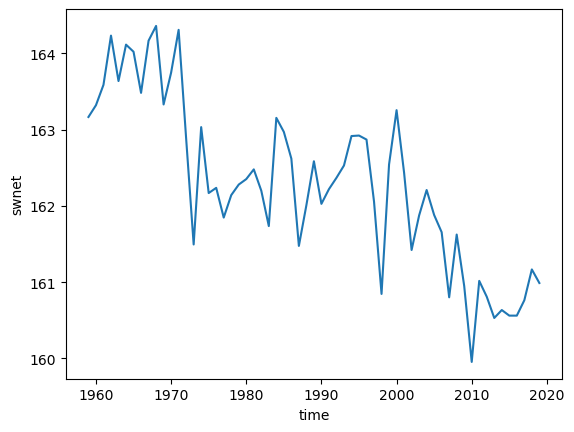

In [8]:
yearly_ds.swnet.plot()

In [9]:
if with_ice_mask:
    output_file = f"{PATH_OUT}{YEAR_START}_{YEAR_FIN}_{out_var_type}_yearly_weighted_means_with_ice_mask.nc"
else:
    output_file = f"{PATH_OUT}{YEAR_START}_{YEAR_FIN}_{out_var_type}_yearly_weighted_means_no_ice_mask.nc"
yearly_ds.to_netcdf(output_file)

print(f"Yearly time series saved to {output_file}")

Yearly time series saved to /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.daily_SST_ERA5/YEARLY/1959_2019_ocn_yearly_weighted_means_with_ice_mask.nc
